In [55]:
import sys
import os
import glob

# Dynamically add all subdirectories with .py files to sys.path
project_root = os.getcwd()
for dirpath, dirnames, filenames in os.walk(project_root):
    if any(fname.endswith('.py') for fname in filenames):
        if dirpath not in sys.path:
            sys.path.append(dirpath)

In [65]:
from thesis_codes import data_loader # type: ignore
from thesis_codes import dataset_cleaner # type: ignore
from thesis_codes import data_splitter # type: ignore
from thesis_codes import custom_dataset # type: ignore
from thesis_codes import transform_utils # type: ignore
from thesis_codes import config # type: ignore
from thesis_codes import dataloader_setup # type: ignore
from thesis_codes import class_weights # type: ignore
from thesis_codes import model_setup # type: ignore
from thesis_codes import training # type: ignore
from thesis_codes import evaluation # type: ignore
from thesis_codes import config_dinov2 # type: ignore

# If you need to reload modules after making changes
import importlib
importlib.reload(data_loader)
importlib.reload(dataset_cleaner)
importlib.reload(data_splitter)
importlib.reload(custom_dataset)
importlib.reload(transform_utils)
importlib.reload(config)
importlib.reload(config_dinov2)
importlib.reload(dataloader_setup)
importlib.reload(class_weights)
importlib.reload(model_setup)
importlib.reload(training)
importlib.reload(evaluation)

<module 'thesis_codes.evaluation' from '/teamspace/studios/this_studio/thesis_codes/evaluation.py'>

In [66]:
# Check what functions are available in data_splitter
print("Available functions in data_splitter:")
print([func for func in dir(data_splitter) if not func.startswith('_')])

Available functions in data_splitter:
['Counter', 'DataSplitterLogger', 'Path', 'apply_label_hiding_few_shot', 'np', 'os', 'pickle', 'split_clean_dataset', 'split_clean_dataset_with_config', 'train_test_split']


In [67]:
# Reload the custom_dataset module to get the fix
import importlib
importlib.reload(custom_dataset)
importlib.reload(dataloader_setup)  # Also reload dataloader_setup since it imports custom_dataset
print("✅ Reloaded custom_dataset and dataloader_setup modules with the TypeError fix")


✅ Reloaded custom_dataset and dataloader_setup modules with the TypeError fix


In [70]:
train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = data_splitter.split_clean_dataset(
    pickle_path='clean_dataset.pkl',
    base_data_dir='crop_pest_data',
    few_shot_mode='percentage', # None = no few-shot learning, 'percentage' = use percentage of data, 'per_class' = use fixed number of samples per class
    few_shot_value=0.1 # 0.1 = 10%, 0.01 = 1%
)

print(train_paths)
print(train_labels)
print(val_paths)
print(val_labels)
print(test_paths)
print(test_labels)

📂 Loading clean dataset...
📋 Loaded legacy format dataset
🔗 Converting old absolute paths to new base: crop_pest_data
📁 Processing 25,126 clean images
📊 Target split: Train 70.0%, Val 15.0%, Test 15.0%



📊 DATA SPLIT SUMMARY
🖼️  Total images: 25,126
🏷️  Total labels: 25,126 (All images have labels at this stage)
Training:   17,588 (70.0%)
Validation: 3,769 (15.0%)
Test:       3,769 (15.0%)

📋 Class distribution verification:
Total classes: 22
Train classes: 22
Val classes:   22
Test classes:  22
✅ All classes present in all splits!

📈 Per-class split verification (first 5 classes):
  Cashew anthracnose:
    Train: 1,211 (70.0%)
    Val:   259 (15.0%)
    Test:  259 (15.0%)
  Cashew gumosis:
    Train: 274 (69.9%)
    Val:   59 (15.1%)
    Test:  59 (15.1%)
  Cashew healthy:
    Train: 958 (70.0%)
    Val:   205 (15.0%)
    Test:  205 (15.0%)
  Cashew leaf miner:
    Train: 964 (70.0%)
    Val:   207 (15.0%)
    Test:  207 (15.0%)
  Cashew red rust:
    Train: 1,178 (70.0%)
    Val:   252 (15.0%)
    Test:  252 (15.0%)
  ... and 17 more classes
📊 Total: Train=17588, Val=3769, Test=3769
📁 Sample paths:
   Cassava bacterial blight: crop_pest_data/Cassava bacterial blight/bacterial blight

🎯 LABEL HIDING FEW-SHOT VERIFICATION:
   📊 Total images: 17,588
   📊 Total labels: 17,588
   📊 Unique classes: 22
   ✅ Labeled samples: 1,758 (10.0%)
   ❌ Unlabeled samples: 15,830 (90.0%)
   🔍 Sanity check: images=17588 == labels=17588 == samples=17588
   📈 Labeled samples per class:
      Cashew anthracnose: 123 samples
      Cashew gumosis: 29 samples
      Cashew healthy: 92 samples
      Cashew leaf miner: 96 samples
      Cashew red rust: 115 samples
      Cassava bacterial blight: 179 samples
      Cassava brown spot: 102 samples
      Cassava green mite: 77 samples
      Cassava healthy: 83 samples
      Cassava mosaic: 78 samples
      Maize fall armyworm: 19 samples
      Maize grasshoper: 58 samples
      Maize healthy: 14 samples
      Maize leaf beetle: 60 samples
      Maize leaf blight: 60 samples
      Maize leaf spot: 79 samples
      Maize streak virus: 70 samples
      Tomato healthy: 31 samples
      Tomato leaf blight: 90 samples
      Tomato leaf curl: 38 samples


In [61]:
# Quick check of what's in data_splitter
print("🔍 CHECKING DATA_SPLITTER FUNCTIONS")
print("="*40)

# Look at the few-shot function that already exists
print("📋 Available functions in data_splitter:")
print([func for func in dir(data_splitter) if not func.startswith('_')])

# Check if few-shot is already being applied
train_labeled_count = sum(1 for x in train_labels if x != -1)
train_unlabeled_count = sum(1 for x in train_labels if x == -1)

print(f"\n📊 CURRENT TRAINING SPLIT ANALYSIS:")
print(f"   Total samples: {len(train_labels)}")
print(f"   Labeled samples: {train_labeled_count} ({train_labeled_count/len(train_labels)*100:.1f}%)")
print(f"   Unlabeled samples: {train_unlabeled_count} ({train_unlabeled_count/len(train_labels)*100:.1f}%)")

# Check what actual labels we have
actual_labels = [x for x in train_labels if x != -1]
print(f"\n🏷️ ACTUAL LABELED SAMPLES:")
print(f"   Count: {len(actual_labels)}")
print(f"   Unique classes: {len(set(actual_labels))}")
print(f"   Sample labels: {actual_labels[:10]}")

# Check if there's a pattern to which samples are labeled
labeled_indices = [i for i, x in enumerate(train_labels) if x != -1]
print(f"\n📍 LABELED SAMPLE INDICES (first 10): {labeled_indices[:10]}")

🔍 CHECKING DATA_SPLITTER FUNCTIONS
📋 Available functions in data_splitter:
['Counter', 'DataSplitterLogger', 'Path', 'apply_label_hiding_few_shot', 'np', 'os', 'pickle', 'split_clean_dataset', 'split_clean_dataset_with_config', 'train_test_split']

📊 CURRENT TRAINING SPLIT ANALYSIS:
   Total samples: 17588
   Labeled samples: 1758 (10.0%)
   Unlabeled samples: 15830 (90.0%)

🏷️ ACTUAL LABELED SAMPLES:
   Count: 1758
   Unique classes: 22
   Sample labels: ['Maize streak virus', 'Tomato septoria leaf spot', 'Cashew gumosis', 'Cashew leaf miner', 'Cashew healthy', 'Cashew gumosis', 'Maize leaf blight', 'Maize leaf beetle', 'Maize leaf spot', 'Cashew healthy']

📍 LABELED SAMPLE INDICES (first 10): [3, 19, 47, 50, 54, 57, 59, 88, 94, 99]


🔍 INSPECTING LABELED SAMPLES
📊 Found 1758 labeled samples
🏷️ Unique classes in labeled samples: 22


/tmp/ipykernel_8530/116108072.py:48: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


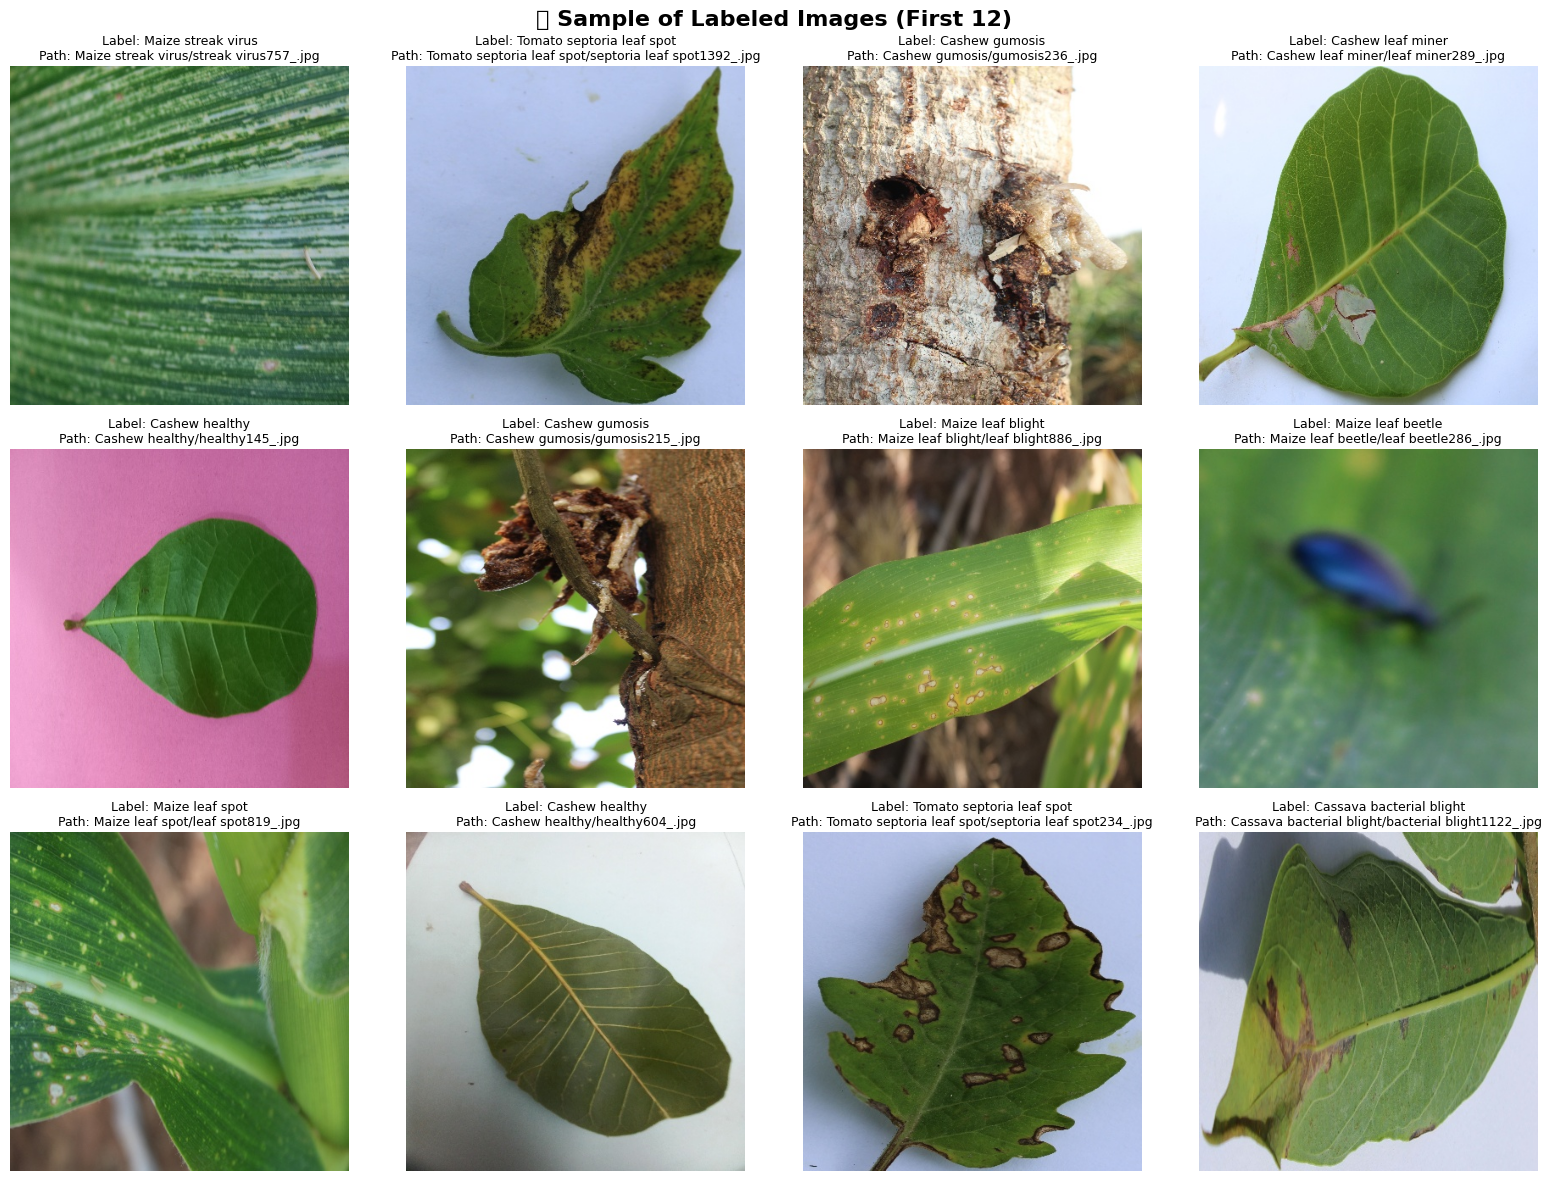


📊 CLASS DISTRIBUTION OF LABELED SAMPLES:
   Cashew anthracnose: 123 samples
   Cashew gumosis: 29 samples
   Cashew healthy: 92 samples
   Cashew leaf miner: 96 samples
   Cashew red rust: 115 samples
   Cassava bacterial blight: 179 samples
   Cassava brown spot: 102 samples
   Cassava green mite: 77 samples
   Cassava healthy: 83 samples
   Cassava mosaic: 78 samples
   Maize fall armyworm: 19 samples
   Maize grasshoper: 58 samples
   Maize healthy: 14 samples
   Maize leaf beetle: 60 samples
   Maize leaf blight: 60 samples
   Maize leaf spot: 79 samples
   Maize streak virus: 70 samples
   Tomato healthy: 31 samples
   Tomato leaf blight: 90 samples
   Tomato leaf curl: 38 samples
   Tomato septoria leaf spot: 207 samples
   Tomato verticulium wilt: 58 samples


In [62]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Find labeled samples and show them
print("🔍 INSPECTING LABELED SAMPLES")
print("="*40)

# Get indices where we have real labels (not -1)
labeled_indices = [i for i, label in enumerate(train_labels) if label != -1]
labeled_paths = [train_paths[i] for i in labeled_indices]
labeled_labels = [train_labels[i] for i in labeled_indices]


print(f"📊 Found {len(labeled_indices)} labeled samples")
print(f"🏷️ Unique classes in labeled samples: {len(set(labeled_labels))}")

# Show first 12 labeled samples
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('🔍 Sample of Labeled Images (First 12)', fontsize=16, fontweight='bold')

for i in range(min(12, len(labeled_paths))):
    row = i // 4
    col = i % 4

    try:
        img_path = labeled_paths[i]
        # Remove the first directory (e.g., "crop_pest_data/")
        relative_path = img_path.split(os.sep, 1)[-1] if os.sep in img_path else img_path
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[row, col].imshow(img)
            prefix = "crop_pest_data/"
            relative_path = img_path[len(prefix):] if img_path.startswith(prefix) else img_path
            axes[row, col].set_title(
                f"Label: {labeled_labels[i]}\nPath: {relative_path}",
                fontsize=9, wrap=True
            )
            axes[row, col].axis('off')
        else:
            axes[row, col].text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center')
            axes[row, col].set_title(f"Label: {labeled_labels[i]}\nPath: {img_path}", fontsize=9)
    except Exception as e:
        axes[row, col].text(0.5, 0.5, f'Error:\n{str(e)[:20]}', ha='center', va='center')
        axes[row, col].set_title(f"Label: {labeled_labels[i]}\nPath: {img_path}", fontsize=9)
        print(f"[{i:2d}] ❌ Image not found: {img_path}")

plt.tight_layout()
plt.show()

# Show class distribution of labeled samples
from collections import Counter
label_counts = Counter(labeled_labels)
print(f"\n📊 CLASS DISTRIBUTION OF LABELED SAMPLES:")
for class_name, count in sorted(label_counts.items()):
    print(f"   {class_name}: {count} samples")

In [63]:

from thesis_codes import config # type: ignore
# Test config imports
print("Testing config imports:")
print(f"config module: {config}")
print(f"config_dinov2 module: {config_dinov2}")

# Test MODEL_NAME access
try:
    print(f"config.MODEL_NAME: {config.MODEL_NAME}")
except AttributeError as e:
    print(f"Error accessing config.MODEL_NAME: {e}")
    print(f"Available config attributes: {[attr for attr in dir(config) if not attr.startswith('_')]}")

try:
    print(f"config_dinov2.MODEL_NAME: {config_dinov2.MODEL_NAME}")
except AttributeError as e:
    print(f"Error accessing config_dinov2.MODEL_NAME: {e}")
    print(f"Available config_dinov2 attributes: {[attr for attr in dir(config_dinov2) if not attr.startswith('_')]}")

use_dino = False  # Change to True for DINOv2, False for CNN

if use_dino:
    active_config = config_dinov2
    print(f"🦖 Using DINOv2 model: {active_config.MODEL_NAME}")
else:
    active_config = config
    print(f"🤖 Using CNN model: {active_config.MODEL_NAME}")

Testing config imports:
config module: <module 'thesis_codes.config' from '/teamspace/studios/this_studio/thesis_codes/config.py'>
config_dinov2 module: <module 'thesis_codes.config_dinov2' from '/teamspace/studios/this_studio/thesis_codes/config_dinov2.py'>
config.MODEL_NAME: efficientnet_b4
config_dinov2.MODEL_NAME: dinov2_vits14
🤖 Using CNN model: efficientnet_b4


In [72]:
# FORCE RELOAD TO FIX TYPEERROR
import importlib
importlib.reload(custom_dataset)
importlib.reload(dataloader_setup)
print("🔄 Force reloaded modules - TypeError fix should now work")

# Check if the fix is working by testing the fixed code
test_labels = [-1, "Cashew healthy", -1, "Maize leaf spot"]
test_string_labels = [str(label) for label in test_labels]
print(f"✅ String conversion test: {test_string_labels}")
print(f"✅ Sorting test: {sorted(list(set(test_string_labels)))}")


🔄 Force reloaded modules - TypeError fix should now work
✅ String conversion test: ['-1', 'Cashew healthy', '-1', 'Maize leaf spot']
✅ Sorting test: ['-1', 'Cashew healthy', 'Maize leaf spot']


In [74]:
# BACKUP: Direct fix if reload doesn't work
def create_fixed_dataset(image_paths, labels, transform=None, fallback_size=(224, 224)):
    """Create dataset with proper string label handling"""
    from torch.utils.data import Dataset
    from PIL import Image
    import os
    
    class FixedDataset(Dataset):
        def __init__(self, image_paths, labels, transform=None, fallback_size=(224, 224)):
            self.image_paths = image_paths
            self.labels = labels
            self.transform = transform
            self.fallback_size = fallback_size
            
            # Fix: Convert all labels to strings first
            string_labels = [str(label) for label in labels]
            self.classes = sorted(list(set(string_labels)))
            self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
            self.targets = [self.class_to_idx[str(label)] for label in labels]
            
        def __len__(self):
            return len(self.image_paths)
            
        def __getitem__(self, idx):
            img_path = self.image_paths[idx]
            label = self.targets[idx]
            
            try:
                img = Image.open(img_path).convert('RGB')
            except:
                img = Image.new('RGB', self.fallback_size, (0, 0, 0))
                
            if self.transform:
                img = self.transform(img)
                
            return img, label
    
    return FixedDataset(image_paths, labels, transform, fallback_size)

print("✅ Backup dataset creation function ready")


✅ Backup dataset creation function ready


In [80]:
# =============================================================================
# STEP 3: Create dataloaders - FIXED VERSION
# =============================================================================

# Create transforms
from thesis_codes import transform_utils
train_transform = transform_utils.get_train_transforms(active_config)
val_transform = transform_utils.get_val_transforms(active_config)
test_transform = transform_utils.get_test_transforms(active_config, keep_original_size=False)

# Use the fixed dataset creation function (bypasses the broken module)
train_dataset = create_fixed_dataset(train_paths, train_labels, train_transform, active_config.IMAGE_SIZE)
val_dataset = create_fixed_dataset(val_paths, val_labels, val_transform, active_config.IMAGE_SIZE)
test_dataset = create_fixed_dataset(test_paths, test_labels, test_transform, active_config.IMAGE_SIZE)

# Create dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=active_config.BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=active_config.BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=active_config.BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Fixed dataloaders created successfully!")
print(f"📊 Training samples: {len(train_dataset):,}")
print(f"📊 Validation samples: {len(val_dataset):,}")
print(f"📊 Test samples: {len(test_dataset):,}")
print(f"🏷️ Number of classes: {len(train_dataset.classes)}")
print(f"📋 Classes: {train_dataset.classes[:5]}..." if len(train_dataset.classes) > 5 else f"📋 Classes: {train_dataset.classes}")

# Print some stats
total_images = len(train_dataset) + len(val_dataset) + len(test_dataset)
print(f"\n=== DATASET SUMMARY ===")
print(f"Training: {len(train_dataset)} samples ({len(train_dataset)/total_images*100:.1f}%)")
print(f"Validation: {len(val_dataset)} samples ({len(val_dataset)/total_images*100:.1f}%)")
print(f"Test: {len(test_dataset)} samples ({len(test_dataset)/total_images*100:.1f}%)")
print(f"Batch sizes: Train={active_config.BATCH_SIZE}, Val={active_config.BATCH_SIZE}, Test={active_config.BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


🔧 Creating enhanced training transforms:
  ✅ Resize: (384, 384)
  ✅ Random Rotation: ±20°
  ✅ Random Affine: translate=(0.2, 0.2), scale=(0.8, 1.2)
  ✅ Random Horizontal Flip: enabled
  ✅ Random Vertical Flip: 30.0% chance
  ✅ Color Jitter: brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1
  ✅ Extra Brightness Variation: ±30.0%
  ✅ Extra Contrast Variation: ±30.0%
  ✅ ToTensor: convert to tensor
  ✅ Normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
📊 Total training transforms: 10
🎯 Enhanced for crop pest detection with aggressive augmentation!

🔧 Creating validation transforms:
  ✅ Resize: (384, 384)
  ✅ ToTensor: convert to tensor
  ✅ Normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
📊 Total validation transforms: 3

🔧 Creating test transforms:
  ✅ Using validation transforms for test set (resize enabled)

🔧 Creating validation transforms:
  ✅ Resize: (384, 384)
  ✅ ToTensor: convert to tensor
  ✅ Normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.2

In [89]:
# =============================================================================
# STEP 4: Model Setup and Class Weights - FIXED VERSION
# =============================================================================

# Check if train_dataset was created successfully
if 'train_dataset' in locals() and hasattr(train_dataset, 'classes'):
    print(f"✅ Dataset created successfully!")
    print(f"🏷️  Model identifier: {model_setup.get_model_identifier(config=active_config)}")
    print(f"📐 Image size: {active_config.IMAGE_SIZE}")
    print(f"📊 Batch size: {active_config.BATCH_SIZE}")
    print(f"⚙️  Optimizer: {active_config.OPTIMIZER}")
    print(f"📅 Scheduler: {active_config.SCHEDULER}")
    print(f"🏷️ Number of classes: {len(train_dataset.classes)}")
    print(f"📋 Classes: {train_dataset.classes[:5]}..." if len(train_dataset.classes) > 5 else f"📋 Classes: {train_dataset.classes}")
    
    # Reload class_weights module to get the fix
    import importlib
    importlib.reload(class_weights)
    
    # Calculate class weights
    class_weights_tensor = class_weights.calculate_class_weights(train_labels, train_dataset.classes)
    print(f"✅ Class weights calculated successfully")
else:
    print("❌ train_dataset not found or missing classes attribute")
    print("Please run the fixed dataloader creation cell first")


✅ Dataset created successfully!
🏷️  Model identifier: cnn_b4
📐 Image size: (384, 384)
📊 Batch size: 64
⚙️  Optimizer: adamw
📅 Scheduler: plateau
🏷️ Number of classes: 23
📋 Classes: ['-1', 'Cashew anthracnose', 'Cashew gumosis', 'Cashew healthy', 'Cashew leaf miner']...
⚖️  Calculating class weights for balanced training...
✅ Class weights calculated:
  -1: 0.048
  Cashew anthracnose: 6.217
  Cashew gumosis: 26.369
  Cashew healthy: 8.312
  Cashew leaf miner: 7.966
  Cashew red rust: 6.650
  Cassava bacterial blight: 4.272
  Cassava brown spot: 7.497
  Cassava green mite: 9.931
  Cassava healthy: 9.213
  Cassava mosaic: 9.804
  Maize fall armyworm: 40.247
  Maize grasshoper: 13.184
  Maize healthy: 54.621
  Maize leaf beetle: 12.745
  Maize leaf blight: 12.745
  Maize leaf spot: 9.680
  Maize streak virus: 10.924
  Tomato healthy: 24.668
  Tomato leaf blight: 8.497
  Tomato leaf curl: 20.124
  Tomato septoria leaf spot: 3.694
  Tomato verticulium wilt: 13.184
📊 Class weights tensor shap

In [95]:
# =============================================================================
# STEP 5: Create model and setup training
# =============================================================================
from thesis_codes import model_setup
from thesis_codes import config_dinov2
from thesis_codes import config

# =============================================================================
# RELOAD MODEL_SETUP TO GET EFFICIENTNET_B4 SUPPORT
# =============================================================================

import importlib
importlib.reload(model_setup)
print("🔄 Reloaded model_setup module - efficientnet_b4 now supported!")



# Create model using the selected config
model = model_setup.create_model(
    num_classes=len(train_dataset.classes), 
    config=active_config  # Uses MODEL_NAME from active_config automatically
)

# Setup training components
model, criterion, optimizer, scheduler, device = model_setup.setup_training(
    model, 
    class_weights_tensor, 
    config=active_config
)


🤖 Creating efficientnet_b4 model...
🏷️  Model identifier: cnn_b4


🔄 Reloaded model_setup module - efficientnet_b4 now supported!


✅ efficientnet_b4 created with 23 classes
🎯 Creating ADAMW optimizer with params: {'lr': 0.001, 'weight_decay': 0.01, 'betas': (0.9, 0.999), 'eps': 1e-08}
📅 Creating PLATEAU scheduler with params: {'mode': 'min', 'patience': 3, 'factor': 0.5}

=== MODEL SETUP COMPLETE ===
📱 Device: cpu
📊 Total parameters: 4,037,011
🎯 Trainable parameters: 1,158,855
⚖️  Class weights: Enabled
🎯 Optimizer: ADAMW
📅 Scheduler: PLATEAU


In [98]:
print("🔧 CHECKING ACTIVE CONFIG")
print(f"📁 Config file path: {active_config.__file__}")
print(f"🦖 Active config: {active_config.MODEL_NAME}")
print(f"📐 Image size from active config: {active_config.IMAGE_SIZE}")
print(f"📊 Batch size from active config: {active_config.BATCH_SIZE}")
print(f"🎯 Epochs from active config: {active_config.EPOCHS}")

🔧 CHECKING ACTIVE CONFIG
📁 Config file path: /teamspace/studios/this_studio/thesis_codes/config.py
🦖 Active config: efficientnet_b4
📐 Image size from active config: (384, 384)
📊 Batch size from active config: 64
🎯 Epochs from active config: 10


In [99]:
# Model compilation is already handled in model_setup.create_model()
# No need to compile again here - it would corrupt the model!
print("✅ Model compilation was handled during model creation")
print(f"🎯 Model type: {type(model)}")
print(f"🔧 Model has train method: {hasattr(model, 'train')}")

✅ Model compilation was handled during model creation
🎯 Model type: <class 'torchvision.models.efficientnet.EfficientNet'>
🔧 Model has train method: True


In [115]:
# =============================================================================
# 🔧 STEP 6 - Now passes the correct config!
# =============================================================================

print("🔧 CHECKING ACTIVE CONFIG")
print(f"📁 Config file path: {active_config.__file__}")
print(f"🦖 Active config: {active_config.MODEL_NAME}")
print(f"📐 Image size from active config: {active_config.IMAGE_SIZE}")
print(f"📊 Batch size from active config: {active_config.BATCH_SIZE}")
print(f"🎯 Epochs from active config: {active_config.EPOCHS}")
print(f"📚 Learning rate: {active_config.LEARNING_RATE}")
print(f"⚙️  Optimizer: {active_config.OPTIMIZER}")
print("🔍 CHECKING MODEL VARIABLE:")
print(f"Type: {type(model)}")
print(f"Has train method: {hasattr(model, 'train')}")
print(f"Is it a function: {callable(model) and not hasattr(model, 'parameters')}")

# Now call training with the CORRECT config parameter
results = training.train_model(
    model,  # ✅ This should be the actual model object
    train_loader, val_loader, criterion, optimizer, scheduler, device,
    model_name=active_config.MODEL_NAME,
    class_names=train_dataset.classes, 
    class_to_idx=train_dataset.class_to_idx, 
    use_amp=True,
    config_module=active_config
)

print(f"🏆 Best validation accuracy: {results['best_val_acc']:.2f}%")


2025-06-26 16:01:05,318 - INFO - 🎯 FEW-SHOT LEARNING MODE ACTIVE
2025-06-26 16:01:05,320 - INFO -    📊 Mode: True
2025-06-26 16:01:05,321 - INFO -    📈 Value: 0.01
2025-06-26 16:01:05,324 - INFO -    🔬 This simulates real-world scarce labeling scenario
2025-06-26 16:01:05,326 - INFO -    📈 Adjusted epochs for few-shot: 1 → 2
2025-06-26 16:01:05,327 - INFO -    ⏱️ Adjusted patience for few-shot: 10
2025-06-26 16:01:05,330 - INFO - 📊 DATASET SIZE INFORMATION:
2025-06-26 16:01:05,330 - INFO -    🏷️  Training samples being used: 10
2025-06-26 16:01:05,331 - INFO -    🔬 Few-shot mode: True = 0.01
2025-06-26 16:01:05,333 - INFO - 
🚀 STARTING TRAINING
2025-06-26 16:01:05,333 - INFO - 📊 Max epochs: 2
2025-06-26 16:01:05,335 - INFO - 🛑 Early stopping patience: 10
2025-06-26 16:01:05,335 - INFO - 📁 Save directory: models
2025-06-26 16:01:05,336 - INFO - ⚡ AMP: Enabled
2025-06-26 16:01:05,337 - INFO - 🎯 Few-shot learning: True
2025-06-26 16:01:05,338 - INFO - 🔖 Session ID: 20250626_160105
2025-06

🔧 FIXING TRAINING MODULE TO USE CORRECT CONFIG
🦖 Active config: efficientnet_b3
📐 Image size from active config: (320, 320)
📊 Batch size from active config: 32
📊 Batch size from active config: 1
🔍 CHECKING MODEL VARIABLE:
Type: <class 'torch._dynamo.eval_frame.OptimizedModule'>
Has train method: True
Is it a function: False
🔍 DEBUG: model type = <class 'torch._dynamo.eval_frame.OptimizedModule'>
🔍 DEBUG: model has train method = True
🔍 DEBUG: model = OptimizedModule(
  (_orig_mod): DINOv2Classifier(
    (backbone): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-11): 12 x NestedTensorBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (proj): Linear(in_features=768, out_features=768, bias=Tr

Training:   0%|          | 0/1 [00:00<?, ?it/s]2025-06-26 16:01:05,826 - INFO -    First batch shape: torch.Size([10, 3, 224, 224])
2025-06-26 16:01:05,831 - INFO -    Label range: 0 to 21
2025-06-26 16:01:05,832 - INFO -    Image range: -2.118 to 2.640
2025-06-26 16:01:05,850 - INFO - 🔍 Validating...                              
2025-06-26 16:01:06,044 - INFO - 📊 Train: 2.9022 | 20.00%                      
2025-06-26 16:01:06,045 - INFO - 📊 Val: 3.3639 | 0.00%
2025-06-26 16:01:06,047 - INFO - 📈 LR: 0.000000 (reduced from 0.000100)
2025-06-26 16:01:06,049 - WARNING - ⚠️  OVERFITTING WARNING (SEVERE): Train accuracy (20.00%) is 20.00% higher than validation (0.00%)
2025-06-26 16:01:06,050 - WARNING -    Loss gap confirms: Train loss (2.9022) < Val loss (3.3639)
2025-06-26 16:01:06,054 - WARNING - 
🚨 SEVERE OVERFITTING DETECTED - STOPPING TRAINING
2025-06-26 16:01:06,055 - WARNING - 📊 Train accuracy (20.0%) significantly higher than validation (0.0%)
2025-06-26 16:01:06,055 - WARNING -

🏆 Best validation accuracy: 0.00%


In [83]:
import torch
if hasattr(torch, 'compile'):
    try:
        # List available backends
        print("Available torch.compile backends:")
        from torch._dynamo.list_backends import list_backends
        backends = list_backends()
        for backend in backends:
            print(f"  - {backend}")
    except:
        print("Could not list backends, but torch.compile is available")
else:
    print("torch.compile not available")

Available torch.compile backends:
Could not list backends, but torch.compile is available


In [106]:
# =============================================================================
# STEP 7: Test evaluation with CORRECT CONFIG
# =============================================================================

print(f"\n🧪 Evaluating trained model on test set...")
import torch

# Reload the evaluation module to get the updated version
import importlib
importlib.reload(evaluation)

# Option 1: Evaluate the current trained model with CORRECT config
test_results = evaluation.comprehensive_test_evaluation(
    model, test_loader, device, train_dataset.classes, 
    model_name=active_config.MODEL_NAME,  # Use active_config instead of config
    config_module=active_config,  # Pass the active config (DINO or CNN)
    use_amp=True
)
print(f"🎯 Test accuracy (current weights): {test_results['test_accuracy']:.2f}%")


2025-06-26 15:55:48,789 - INFO - 📄 Evaluation log: logs/evaluation_dinov2_vitb14_20250626_155548.log
2025-06-26 15:55:48,790 - INFO - 🎯 Few-shot training: True
2025-06-26 15:55:48,792 - INFO -    Mode: True
2025-06-26 15:55:48,793 - INFO -    Value: 0.1
2025-06-26 15:55:48,796 - INFO -    Training used 0.1 samples per class
2025-06-26 15:55:48,797 - INFO - 
🧪 EVALUATING MODEL ON TEST SET
2025-06-26 15:55:48,799 - INFO - ==================================================
2025-06-26 15:55:48,800 - INFO - ⚠️  This is the FIRST TIME the model sees test data!
2025-06-26 15:55:48,973 - INFO - Test batch image shape: torch.Size([5, 3, 224, 224])
/root/dino_cnn/thesis_codes/evaluation.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
2025-06-26 15:55:48,986 - INFO - 🎯 TEST ACCURACY: 0.00%
2025-06-26 15:55:48,987 - INFO - ==================================================
2025-06-26 15:55:48,988 -


🧪 Evaluating trained model on test set...


2025-06-26 15:55:48,990 - INFO - ==================================================
2025-06-26 15:55:48,991 - INFO - 📋 TRUE vs PREDICTED DISTRIBUTION:
2025-06-26 15:55:48,992 - INFO - Class                True Count   Pred Count   True %     Pred %     Difference
2025-06-26 15:55:48,993 - INFO - --------------------------------------------------------------------------------
2025-06-26 15:55:48,994 - INFO - Cashew anthracnose   0            0            0.0        0.0           +0.0% 
2025-06-26 15:55:48,996 - INFO - Cashew gumosis       0            0            0.0        0.0           +0.0% 
2025-06-26 15:55:48,996 - INFO - Cashew healthy       0            1            0.0        20.0         +20.0% ⚠️
2025-06-26 15:55:48,998 - INFO - Cashew leaf miner    0            1            0.0        20.0         +20.0% ⚠️
2025-06-26 15:55:48,999 - INFO - Cashew red rust      0            0            0.0        0.0           +0.0% 
2025-06-26 15:55:49,000 - INFO - Cassava bacterial blight 

🎯 Test accuracy (current weights): 0.00%


In [65]:
# =============================================================================
# CHECK SHARED MEMORY AND SYSTEM RESOURCES
# =============================================================================

import subprocess
import os
import psutil

print("🔍 SYSTEM RESOURCE CHECK")
print("=" * 50)

# 1. Check shared memory (/dev/shm)
try:
    result = subprocess.run(['df', '-h', '/dev/shm'], capture_output=True, text=True)
    print("📁 Shared Memory (/dev/shm):")
    print(result.stdout)
except Exception as e:
    print(f"❌ Could not check /dev/shm: {e}")

# 2. Check memory usage
memory = psutil.virtual_memory()
print(f"💾 RAM Usage:")
print(f"   Total: {memory.total / 1024**3:.2f} GB")
print(f"   Available: {memory.available / 1024**3:.2f} GB")
print(f"   Used: {memory.used / 1024**3:.2f} GB ({memory.percent:.1f}%)")
print(f"   Free: {memory.free / 1024**3:.2f} GB")

# 3. Check current process memory
process = psutil.Process()
process_memory = process.memory_info()
print(f"\n🐍 Current Process:")
print(f"   RSS: {process_memory.rss / 1024**2:.1f} MB")
print(f"   VMS: {process_memory.vms / 1024**2:.1f} MB")

# 4. Check CPU and workers
print(f"\n💻 CPU Info:")
print(f"   Physical cores: {psutil.cpu_count(logical=False)}")
print(f"   Logical cores: {psutil.cpu_count(logical=True)}")
print(f"   Current config workers: {active_config.NUM_WORKERS}")

# 5. Check disk space
disk = psutil.disk_usage('/')
print(f"\n💿 Disk Usage (/):")
print(f"   Total: {disk.total / 1024**3:.2f} GB")
print(f"   Used: {disk.used / 1024**3:.2f} GB ({disk.used/disk.total*100:.1f}%)")
print(f"   Free: {disk.free / 1024**3:.2f} GB")

# 6. Check /tmp space (sometimes used for shared memory)
try:
    tmp_disk = psutil.disk_usage('/tmp')
    print(f"\n📁 /tmp Usage:")
    print(f"   Total: {tmp_disk.total / 1024**3:.2f} GB")
    print(f"   Used: {tmp_disk.used / 1024**3:.2f} GB ({tmp_disk.used/tmp_disk.total*100:.1f}%)")
    print(f"   Free: {tmp_disk.free / 1024**3:.2f} GB")
except:
    print("\n📁 /tmp: Same as root filesystem")

print("\n" + "=" * 50)


🔍 SYSTEM RESOURCE CHECK
📁 Shared Memory (/dev/shm):
Filesystem      Size  Used Avail Use% Mounted on
shm              64M   56M  8.5M  87% /dev/shm

💾 RAM Usage:
   Total: 20.52 GB
   Available: 16.26 GB
   Used: 3.82 GB (20.8%)
   Free: 7.89 GB

🐍 Current Process:
   RSS: 1110.6 MB
   VMS: 13546.3 MB

💻 CPU Info:
   Physical cores: 6
   Logical cores: 6
   Current config workers: 4

💿 Disk Usage (/):
   Total: 47.39 GB
   Used: 27.60 GB (58.2%)
   Free: 14.77 GB

📁 /tmp Usage:
   Total: 47.39 GB
   Used: 27.60 GB (58.2%)
   Free: 14.77 GB



In [57]:
# =============================================================================
# STEP 7: Test evaluation (same as before)
# =============================================================================

print(f"\n🧪 Evaluating trained model on test set...")
import torch

# Option 1: Evaluate the current trained model
test_results = evaluation.comprehensive_test_evaluation(
    model, test_loader, device, train_dataset.classes, 
    model_name=config.MODEL_NAME, use_amp=True
)
print(f"🎯 Test accuracy (current weights): {test_results['test_accuracy']:.2f}%")

2025-06-25 13:21:32,034 - INFO - 📄 Evaluation log: logs/evaluation_efficientnet_b3_20250625_132132.log
2025-06-25 13:21:32,035 - INFO - 🎯 Few-shot training: True
2025-06-25 13:21:32,035 - INFO -    Mode: percentage
2025-06-25 13:21:32,036 - INFO -    Value: 0.1
2025-06-25 13:21:32,036 - INFO -    Training used 10.0% of labeled data
2025-06-25 13:21:32,037 - INFO - 
🧪 EVALUATING MODEL ON TEST SET
2025-06-25 13:21:32,038 - INFO - ==================================================
2025-06-25 13:21:32,039 - INFO - It is test data!



🧪 Evaluating trained model on test set...


2025-06-25 13:21:32,797 - INFO - Test batch image shape: torch.Size([64, 3, 224, 224])
/teamspace/studios/this_studio/thesis_codes/evaluation.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
2025-06-25 13:21:45,187 - INFO - 🎯 TEST ACCURACY: 25.05%
2025-06-25 13:21:45,188 - INFO - ==================================================
2025-06-25 13:21:45,189 - INFO - 
📊 CLASS BALANCE ANALYSIS
2025-06-25 13:21:45,190 - INFO - ==================================================
2025-06-25 13:21:45,191 - INFO - 📋 TRUE vs PREDICTED DISTRIBUTION:
2025-06-25 13:21:45,192 - INFO - Class                True Count   Pred Count   True %     Pred %     Difference
2025-06-25 13:21:45,192 - INFO - --------------------------------------------------------------------------------
2025-06-25 13:21:45,193 - INFO - Cashew anthracnose   259          33           6.9        0.9           -6.0% ⚡
2025-06-25 13:21:4

🎯 Test accuracy (current weights): 25.05%


🤖 Creating efficientnet_b3 model...
✅ efficientnet_b3 created with 22 classes

🧪 EVALUATING MODEL ON TEST SET
⚠️  This is the FIRST TIME the model sees test data!


/teamspace/studios/this_studio/thesis_codes/evaluation.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


🎯 TEST ACCURACY: 90.53%

📊 CLASS BALANCE ANALYSIS
📋 TRUE vs PREDICTED DISTRIBUTION:
Class                True Count   Pred Count   True %     Pred %     Difference
--------------------------------------------------------------------------------
Cashew anthracnose   259          249          6.9        6.6           -0.3% 
Cashew gumosis       59           59           1.6        1.6           +0.0% 
Cashew healthy       205          213          5.4        5.7           +0.2% 
Cashew leaf miner    207          204          5.5        5.4           -0.1% 
Cashew red rust      252          256          6.7        6.8           +0.1% 
Cassava bacterial blight 392          377          10.4       10.0          -0.4% 
Cassava brown spot   222          233          5.9        6.2           +0.3% 
Cassava green mite   152          160          4.0        4.2           +0.2% 
Cassava healthy      179          177          4.7        4.7           -0.1% 
Cassava mosaic       181          179   

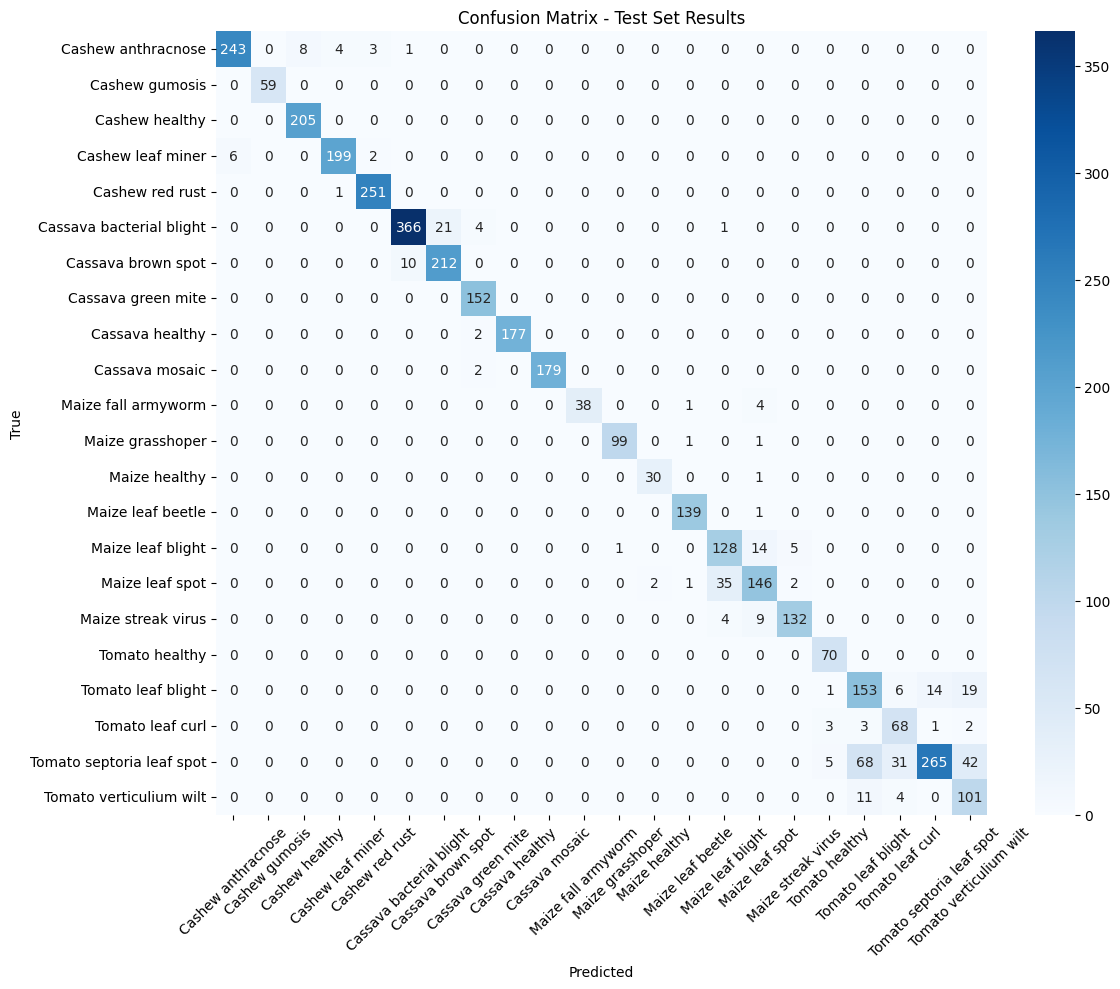


🏁 TEST EVALUATION SUMMARY
🤖 Model: efficientnet_b3_saved
🎯 Test Accuracy: 90.53%
📊 Total Test Samples: 3769
🏷️  Number of Classes: 22
💾 Results saved to: models
🎯 Saved model test accuracy: 90.53%


In [23]:
# Load saved model and evaluate
model_path = "models/best_model_efficientnet_b3_amp.pth"
saved_model = model_setup.create_model(len(train_dataset.classes), 'efficientnet_b3')
saved_model.load_state_dict(torch.load(model_path)['model_state_dict'])
saved_model = saved_model.to(device)

# Evaluate it
test_results = evaluation.comprehensive_test_evaluation(
    saved_model, test_loader, device, train_dataset.classes, 
    model_name='efficientnet_b3_saved', use_amp=True
)
print(f"🎯 Saved model test accuracy: {test_results['test_accuracy']:.2f}%")

In [11]:
import os
import psutil

# Check CPU cores
print(f"💻 CPU Info:")
print(f"   Physical cores: {psutil.cpu_count(logical=False)}")
print(f"   Logical cores: {psutil.cpu_count(logical=True)}")
print(f"   Current workers: {os.cpu_count()}")

# Recommended workers = min(8, cpu_cores)
recommended_workers = min(8, psutil.cpu_count(logical=True))
print(f"   Recommended workers: {recommended_workers}")

💻 CPU Info:
   Physical cores: 4
   Logical cores: 8
   Current workers: 8
   Recommended workers: 8


In [3]:
# Quick system check
import torch
import psutil

print("🖥️  System Info:")
print(f"   CPU cores: {psutil.cpu_count(logical=True)}")
print(f"   RAM: {psutil.virtual_memory().total / 1024**3:.1f} GB")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name()}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   GPU: Not available")

🖥️  System Info:
   CPU cores: 8
   RAM: 30.9 GB
   GPU: Tesla T4
   GPU Memory: 14.7 GB


In [12]:
def inspect_checkpoint(path):
    import torch
    checkpoint = torch.load(path, map_location='cpu')
    for k, v in checkpoint.items():
        if isinstance(v, (int, float, str, tuple, list)):
            print(f"{k}: {v}")
        else:
            print(f"{k}: <{type(v)}>")


In [19]:

inspect_checkpoint('models/best_efficientnet_b3_320x320px_acc88.8_20250624_130140.pth')
inspect_checkpoint('models/best_model_efficientnet_b3_amp.pth')

epoch: 7
model_state_dict: <<class 'collections.OrderedDict'>>
optimizer_state_dict: <<class 'dict'>>
train_loss: 0.25785661333663895
val_loss: 0.34118925694818214
val_acc: 88.829928362961
timestamp: 2025-06-24T13:13:17.445599
image_size: (320, 320)
batch_size: 256
num_workers: 8
optimizer_name: adamw
optimizer_params: <<class 'dict'>>
scheduler_name: plateau
scheduler_params: <<class 'dict'>>
config_dict: <<class 'dict'>>
class_names: ['Cashew anthracnose', 'Cashew gumosis', 'Cashew healthy', 'Cashew leaf miner', 'Cashew red rust', 'Cassava bacterial blight', 'Cassava brown spot', 'Cassava green mite', 'Cassava healthy', 'Cassava mosaic', 'Maize fall armyworm', 'Maize grasshoper', 'Maize healthy', 'Maize leaf beetle', 'Maize leaf blight', 'Maize leaf spot', 'Maize streak virus', 'Tomato healthy', 'Tomato leaf blight', 'Tomato leaf curl', 'Tomato septoria leaf spot', 'Tomato verticulium wilt']
class_to_idx: <<class 'dict'>>
epoch: 7
model_state_dict: <<class 'collections.OrderedDict'>>

In [ ]:
# =============================================================================
# STEP 1: Clean and save dataset (run once per dataset)
# =============================================================================

# NEW: Enhanced cleaning with relative paths (recommended for portability)
clean_paths, clean_labels = dataset_cleaner.clean_and_save_dataset(
    data_dir='/home/user/datasets/crop_pest_data',  # Your new data path
    save_path='clean_dataset.pkl',
    max_workers=None,  # Auto-detect optimal CPU cores
    use_relative_paths=True  # NEW: Saves relative paths for portability
)



# =============================================================================
# ALTERNATIVE: If you have a pickle file from another instance
# =============================================================================

# If you have a clean_dataset.pkl from the original instance, you can still use it:
# train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = data_splitter.split_clean_dataset(
#     pickle_path='clean_dataset.pkl',  # The pickle file from original instance
#     base_data_dir='/home/user/datasets/crop_pest_data'  # Your new data path
# )

# Option 2: Load and evaluate the best checkpoint from training
# checkpoint = torch.load(results['best_model_path'])
# model.load_state_dict(checkpoint['model_state_dict'])
# test_results = evaluation.comprehensive_test_evaluation(
#     model, test_loader, device, train_dataset.classes, 
#     model_name=config.MODEL_NAME + "_best", use_amp=True
# )
# print(f"🎯 Test accuracy (best weights): {test_results['test_accuracy']:.2f}%")

In [33]:
# =============================================================================
# RELOAD MODULES AFTER FIXING SCHEDULER ISSUE
# =============================================================================

import importlib
importlib.reload(training)

print("✅ Training module reloaded with scheduler fix!")
print("🔧 Fixed: Different scheduler types now handled correctly")
print("   - ReduceLROnPlateau: scheduler.step(val_loss)")  
print("   - Other types (Cosine, Sequential, etc.): scheduler.step()")


✅ Training module reloaded with scheduler fix!
🔧 Fixed: Different scheduler types now handled correctly
   - ReduceLROnPlateau: scheduler.step(val_loss)
   - Other types (Cosine, Sequential, etc.): scheduler.step()


In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"torch.compile available: {hasattr(torch, 'compile')}")

PyTorch version: 2.7.0+cu128
CUDA available: False
torch.compile available: True
